# Laboratory Exercise 6: Convolutional Neural Networks (CNNs) for Image-Based Perception

**Name:** Lorenzo Bela, Robert Callorina, Kean Guzon

**Section:** 58036

**Date:** 04/04/2026

**Dataset name:** Lab04 EDA Bias Dataset (bottled water, canned goods, combo, Noodles, Rice)

In [4]:
# Cell 1 - Install and import dependencies
# %pip install seaborn

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix, classification_report

NAME = "Lorenzo Bela, Robert Callorina, Kean Guzon"
SECTION = "58036"
DATE = "04/04/2026"
DATASET_NAME = "Lab04 EDA Bias Dataset"

print(f"Name: {NAME}")
print(f"Section: {SECTION}")
print(f"Date: {DATE}")
print(f"Dataset name: {DATASET_NAME}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Name: Lorenzo Bela, Robert Callorina, Kean Guzon
Section: 58036
Date: 04/04/2026
Dataset name: Lab04 EDA Bias Dataset
PyTorch: 2.11.0+cpu
CUDA available: False
Device: cpu


## Part B) Load and Prepare Dataset

In [5]:
# Cell 2 - Transforms
IMG_SIZE = 64
BATCH_SIZE = 32
NUM_EPOCHS = 30
LR = 1e-3

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "notebook":
    NOTEBOOK_DIR = Path("ml-perception-labs/lab06_cnn/notebook").resolve()

LAB06_DIR = NOTEBOOK_DIR.parent
DATA_DIR = LAB06_DIR / "data" / "raw"
FIGURES_DIR = LAB06_DIR / "outputs" / "figures"
TABLES_DIR = LAB06_DIR / "outputs" / "tables"
LOGS_DIR = LAB06_DIR / "outputs" / "logs"

for p in [FIGURES_DIR, TABLES_DIR, LOGS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Lab06 dir: {LAB06_DIR}")
print(f"Data dir: {DATA_DIR}")

Lab06 dir: c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab06_cnn
Data dir: c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab06_cnn\data\raw


In [6]:
# Cell 3 - Load and split dataset
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATA_DIR}")

full_dataset_aug = ImageFolder(root=DATA_DIR, transform=train_transform)
CLASS_NAMES = full_dataset_aug.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Total images: {len(full_dataset_aug)}")

n_total = len(full_dataset_aug)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

indices = torch.randperm(n_total, generator=torch.Generator().manual_seed(SEED)).tolist()
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

train_set = Subset(full_dataset_aug, train_idx)

full_dataset_eval = ImageFolder(root=DATA_DIR, transform=eval_transform)
val_set = Subset(full_dataset_eval, val_idx)
test_set = Subset(full_dataset_eval, test_idx)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

Classes (5): ['Noodles', 'Rice', 'bottled water', 'canned goods', 'combo']
Total images: 250
Train: 175 | Val: 37 | Test: 38


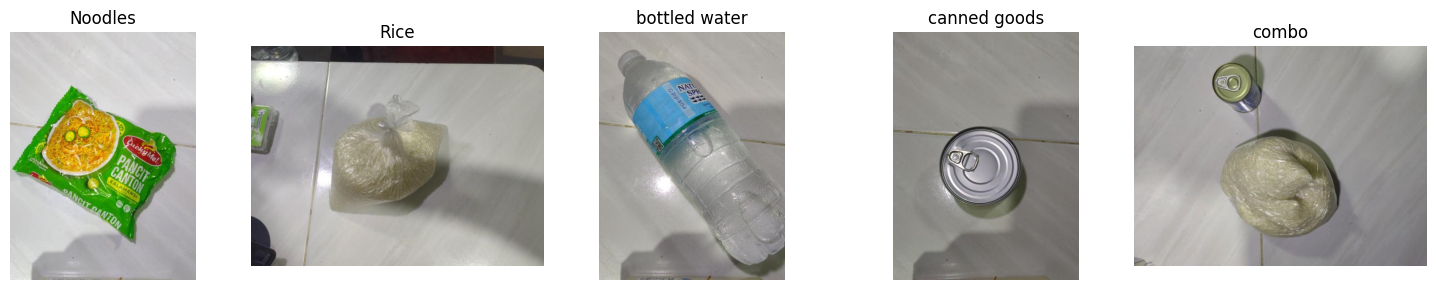

Saved: c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab06_cnn\outputs\figures\lab06_dataset_samples.png


In [7]:
# Cell 3b - Display example images per class and save figure
raw_dataset = ImageFolder(root=DATA_DIR)

sample_paths = {}
for path, label in raw_dataset.samples:
    cls = raw_dataset.classes[label]
    if cls not in sample_paths:
        sample_paths[cls] = path

fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(3 * len(CLASS_NAMES), 3))
if len(CLASS_NAMES) == 1:
    axes = [axes]

for ax, cls in zip(axes, CLASS_NAMES):
    img = Image.open(sample_paths[cls]).convert("RGB")
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab06_dataset_samples.png", dpi=150)
plt.show()
print("Saved:", FIGURES_DIR / "lab06_dataset_samples.png")

## Part C) Define CNN Architectures

In [8]:
# Cell 4 - Model A: ShallowCNN
class ShallowCNN(nn.Module):
    """Baseline: 2 conv blocks, no regularization."""

    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        flat_size = 64 * (IMG_SIZE // 4) * (IMG_SIZE // 4)
        self.fc1 = nn.Linear(flat_size, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model_a = ShallowCNN(NUM_CLASSES).to(DEVICE)
params_a = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
print(f"ShallowCNN | Parameters: {params_a:,}")

ShallowCNN | Parameters: 4,215,237


In [9]:
# Cell 5 - Model B: RegularizedCNN
class RegularizedCNN(nn.Module):
    """3-block CNN with BatchNorm + Dropout for reduced overfitting."""

    def __init__(self, num_classes, dropout_p=0.4):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        flat_size = 128 * (IMG_SIZE // 8) * (IMG_SIZE // 8)
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(flat_size, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.block3(self.block2(self.block1(x)))
        return self.classifier(torch.flatten(x, 1))

model_b = RegularizedCNN(NUM_CLASSES).to(DEVICE)
params_b = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
print(f"RegularizedCNN | Parameters: {params_b:,}")

RegularizedCNN | Parameters: 4,291,077


In [10]:
# Cell 6 - Model C: DeepCNN with residual block
class ResidualBlock(nn.Module):
    """Two conv layers + identity shortcut (1x1 conv if channels differ)."""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv_path = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.conv_path(x) + self.shortcut(x))


class DeepCNN(nn.Module):
    """4-stage deep CNN with skip connection and Global Average Pooling."""

    def __init__(self, num_classes, dropout_p=0.5):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.stage1 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.stage2 = ResidualBlock(64, 128)
        self.stage3 = nn.Sequential(
            nn.MaxPool2d(2, 2),
            ResidualBlock(128, 256),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.stage3(self.stage2(self.stage1(self.stem(x))))
        x = torch.flatten(self.gap(x), 1)
        return self.classifier(x)


model_c = DeepCNN(NUM_CLASSES).to(DEVICE)
params_c = sum(p.numel() for p in model_c.parameters() if p.requires_grad)
print(f"DeepCNN | Parameters: {params_c:,}")

DeepCNN | Parameters: 1,201,445


## Part D) Define Loss Function and Optimizer

In [11]:
# Cell 7 - Loss, optimizer, scheduler factory functions
def make_optimizer(model):
    return optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)


def make_scheduler(optimizer):
    return optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)


criterion = nn.CrossEntropyLoss()
print("Loss: CrossEntropyLoss")
print("Optimizer: Adam (lr=1e-3, weight_decay=1e-4)")
print("Scheduler: StepLR (step=10, gamma=0.5)")

Loss: CrossEntropyLoss
Optimizer: Adam (lr=1e-3, weight_decay=1e-4)
Scheduler: StepLR (step=10, gamma=0.5)


## Part E) Train All Three CNN Models

In [12]:
# Cell 8 - Reusable training loop
def train_model(model, train_loader, val_loader, num_epochs, model_name):
    optimizer = make_optimizer(model)
    scheduler = make_scheduler(optimizer)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    best_weights = None

    for epoch in range(1, num_epochs + 1):
        model.train()
        run_loss, correct, total = 0.0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            run_loss += loss.item() * imgs.size(0)
            correct += out.max(1)[1].eq(labels).sum().item()
            total += labels.size(0)

        train_loss = run_loss / total
        train_acc = correct / total

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out = model(imgs)
                v_loss += criterion(out, labels).item() * imgs.size(0)
                v_correct += out.max(1)[1].eq(labels).sum().item()
                v_total += labels.size(0)

        val_loss = v_loss / v_total
        val_acc = v_correct / v_total

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(
                f"[{model_name}] Ep {epoch:3d} | "
                f"TrainLoss={train_loss:.4f} Acc={train_acc:.4f} | "
                f"ValLoss={val_loss:.4f} Acc={val_acc:.4f}"
            )

    if best_weights is not None:
        model.load_state_dict(best_weights)

    print(f"Best Val Acc ({model_name}): {best_val_acc:.4f}")
    return history

In [13]:
# Cell 9 - Train all three models
print("=" * 55)
print("Training Model A - ShallowCNN")
history_a = train_model(model_a, train_loader, val_loader, NUM_EPOCHS, "ShallowCNN")

print("\n" + "=" * 55)
print("Training Model B - RegularizedCNN")
history_b = train_model(model_b, train_loader, val_loader, NUM_EPOCHS, "RegularizedCNN")

print("\n" + "=" * 55)
print("Training Model C - DeepCNN")
history_c = train_model(model_c, train_loader, val_loader, NUM_EPOCHS, "DeepCNN")

Training Model A - ShallowCNN
[ShallowCNN] Ep   1 | TrainLoss=1.7167 Acc=0.3257 | ValLoss=1.4836 Acc=0.3243
[ShallowCNN] Ep   5 | TrainLoss=0.7403 Acc=0.7486 | ValLoss=0.7904 Acc=0.7838
[ShallowCNN] Ep  10 | TrainLoss=0.2668 Acc=0.9086 | ValLoss=0.4005 Acc=0.8649
[ShallowCNN] Ep  15 | TrainLoss=0.0676 Acc=0.9943 | ValLoss=0.4760 Acc=0.8649
[ShallowCNN] Ep  20 | TrainLoss=0.0414 Acc=0.9943 | ValLoss=0.4867 Acc=0.8649
[ShallowCNN] Ep  25 | TrainLoss=0.0262 Acc=0.9943 | ValLoss=0.4596 Acc=0.8378
[ShallowCNN] Ep  30 | TrainLoss=0.0246 Acc=0.9943 | ValLoss=0.4563 Acc=0.8919
Best Val Acc (ShallowCNN): 0.8919

Training Model B - RegularizedCNN
[RegularizedCNN] Ep   1 | TrainLoss=3.6107 Acc=0.2400 | ValLoss=1.7610 Acc=0.3243
[RegularizedCNN] Ep   5 | TrainLoss=0.9124 Acc=0.6971 | ValLoss=0.6847 Acc=0.7568
[RegularizedCNN] Ep  10 | TrainLoss=0.4485 Acc=0.8457 | ValLoss=0.2594 Acc=0.9189
[RegularizedCNN] Ep  15 | TrainLoss=0.2292 Acc=0.9314 | ValLoss=0.2651 Acc=0.8919
[RegularizedCNN] Ep  20 | T

## Part F) Evaluate CNN Performance

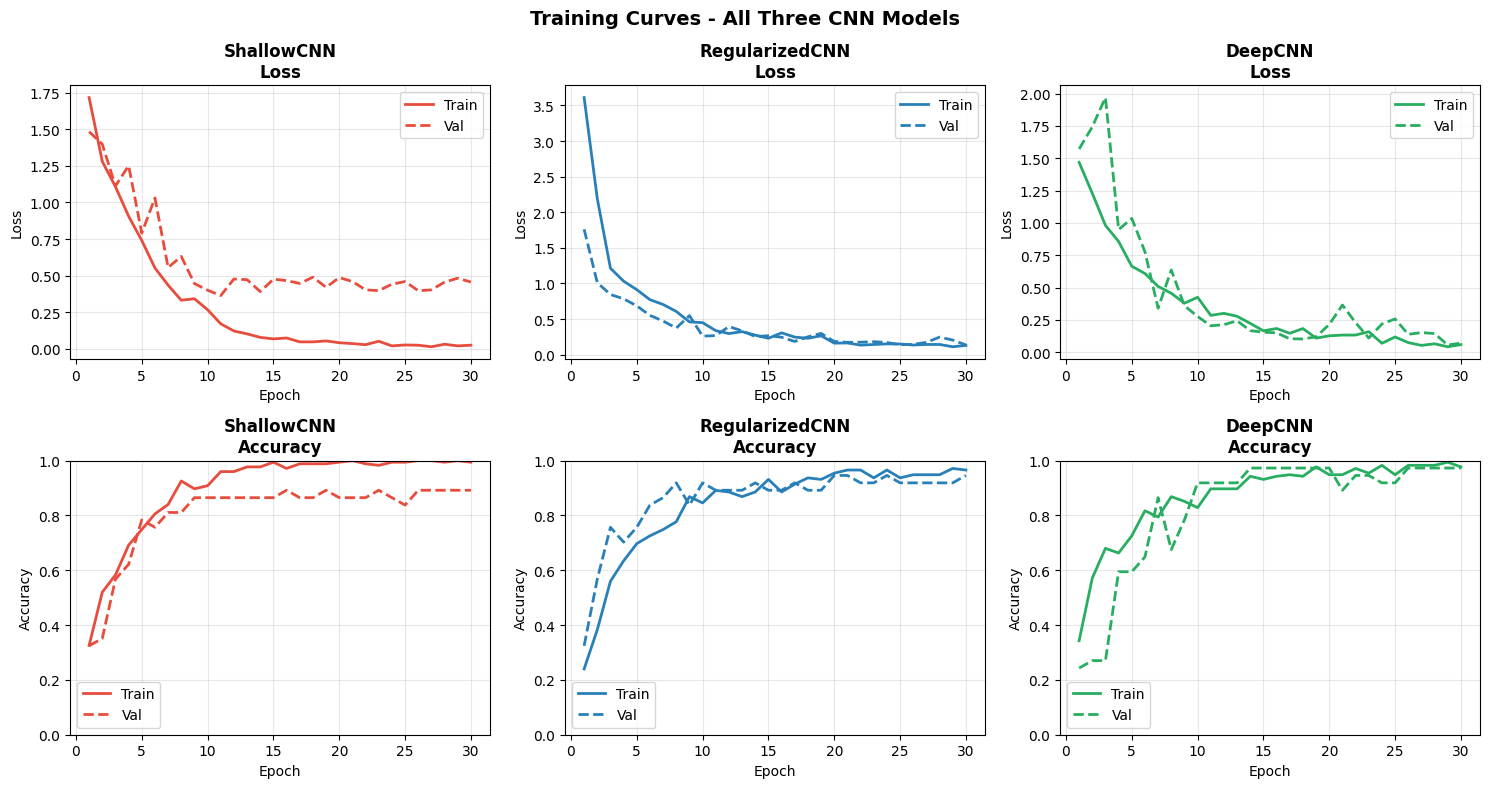

Saved: c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab06_cnn\outputs\figures\lab06_training_curves.png


In [14]:
# Cell 10 - Training curves (loss and accuracy)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
info = [
    (history_a, "ShallowCNN", "#E74C3C"),
    (history_b, "RegularizedCNN", "#2980B9"),
    (history_c, "DeepCNN", "#27AE60"),
]
epochs = range(1, NUM_EPOCHS + 1)

for col, (hist, name, color) in enumerate(info):
    for row, (key_tr, key_vl, ylabel) in enumerate([
        ("train_loss", "val_loss", "Loss"),
        ("train_acc", "val_acc", "Accuracy"),
    ]):
        ax = axes[row, col]
        ax.plot(epochs, hist[key_tr], label="Train", color=color, lw=2)
        ax.plot(epochs, hist[key_vl], label="Val", color=color, lw=2, ls="--")
        ax.set_title(f"{name}\n{ylabel}", fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        if ylabel == "Accuracy":
            ax.set_ylim(0, 1)
        ax.legend()
        ax.grid(alpha=0.3)

plt.suptitle("Training Curves - All Three CNN Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab06_training_curves.png", dpi=150)
plt.show()
print("Saved:", FIGURES_DIR / "lab06_training_curves.png")

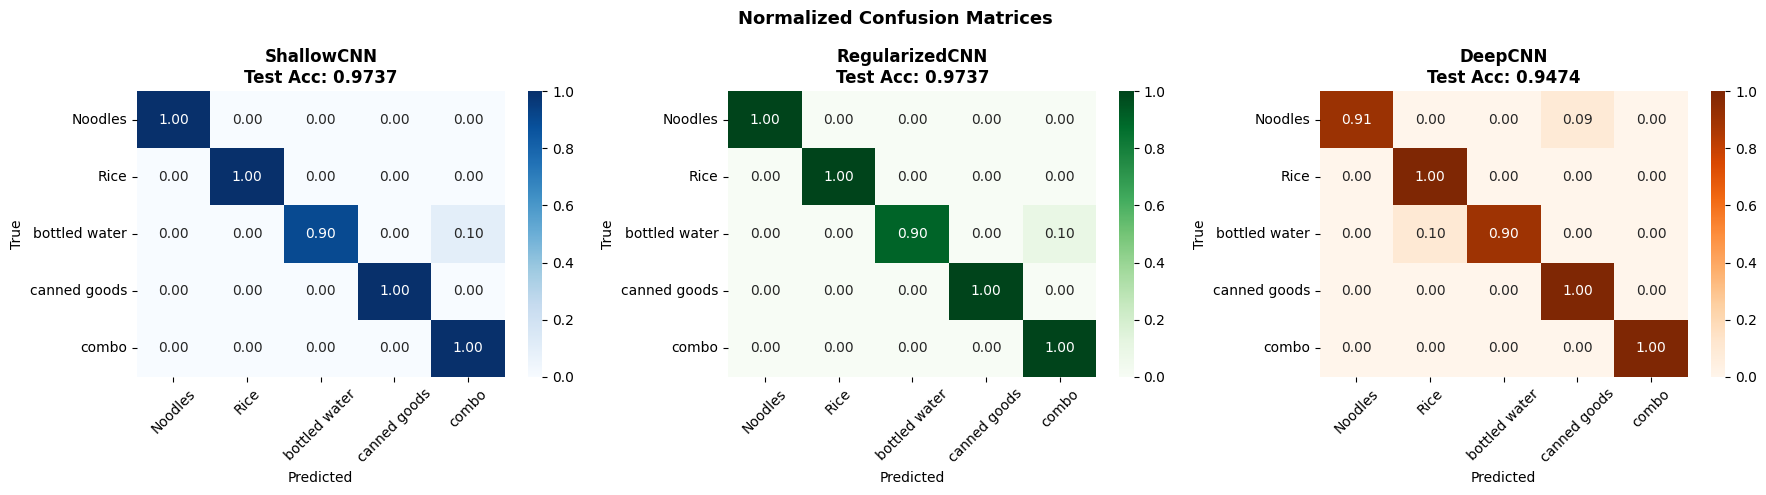

Saved: c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab06_cnn\outputs\figures\lab06_confusion_matrix.png


In [15]:
# Cell 11 - Confusion matrices
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            out = model(imgs.to(DEVICE))
            all_preds.extend(out.max(1)[1].cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (mdl, name, cmap) in zip(
    axes,
    [
        (model_a, "ShallowCNN", "Blues"),
        (model_b, "RegularizedCNN", "Greens"),
        (model_c, "DeepCNN", "Oranges"),
    ],
):
    y_true, y_pred = get_predictions(mdl, test_loader)
    cm = confusion_matrix(y_true, y_pred).astype(float)
    cm /= cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        ax=ax,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cmap=cmap,
    )
    acc = (y_true == y_pred).mean()
    ax.set_title(f"{name}\nTest Acc: {acc:.4f}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Normalized Confusion Matrices", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab06_confusion_matrix.png", dpi=150)
plt.show()
print("Saved:", FIGURES_DIR / "lab06_confusion_matrix.png")

## Part G) Compare CNN Models and Summarize Results

In [16]:
# Cell 12 - Summary comparison table
rows = []
for mdl, name, hist in [
    (model_a, "ShallowCNN", history_a),
    (model_b, "RegularizedCNN", history_b),
    (model_c, "DeepCNN", history_c),
]:
    y_true, y_pred = get_predictions(mdl, test_loader)
    acc = (y_true == y_pred).mean()
    params = sum(p.numel() for p in mdl.parameters() if p.requires_grad)
    best_val = max(hist["val_acc"])
    rows.append(
        {
            "Model": name,
            "Parameters": f"{params:,}",
            "Best Val Acc": f"{best_val:.4f}",
            "Test Accuracy": f"{acc:.4f}",
        }
    )

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv(TABLES_DIR / "lab06_model_comparison.csv", index=False)
print("Saved:", TABLES_DIR / "lab06_model_comparison.csv")

         Model Parameters Best Val Acc Test Accuracy
    ShallowCNN  4,215,237       0.8919        0.9737
RegularizedCNN  4,291,077       0.9459        0.9737
       DeepCNN  1,201,445       0.9730        0.9474
Saved: c:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab06_cnn\outputs\tables\lab06_model_comparison.csv
